In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from helpers_takarada import * 
from module_takarada import *
import matplotlib
import seaborn as sns
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-8,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-8,
'dmu' : 1.5,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-8,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 1.5,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

def get_palette_hex(palette_name, N):
    return sns.color_palette(palette_name, n_colors=N).as_hex()

(np.complex128(0.5779527597813369-1.5228360666387758e-19j),
 np.complex128(0.11365029939292501-4.677238007707099e-18j),
 np.float64(1.4757460764170895))

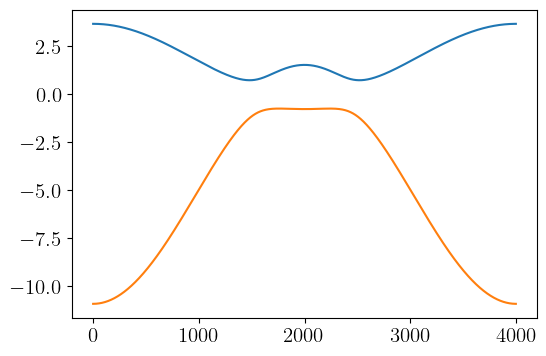

In [269]:
''' 1. generate ground state of some excitonic insulator model '''
a = 1.
b = 0.2

t12 = 0.1
delta = 0.

t = 3.0
t_ = 1.
Vc = 1.0
Vb = 3.0

mu0 = 0.
include_hartree = True

Nk = 4000

gap = -4.

epsilon = 0.5*(gap + 2*t_ + 2*t)
epsilon_ = epsilon

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
plt.plot(m.energije[1]-m.mu)
plt.plot(m.energije[0]-m.mu)
m.delta_b, m.delta_c, m.gap

In [270]:
''' 2. go to small but finite temperature '''
beta0 = 50
scale = 1.008
betas = beta0/scale**np.arange(1,3)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas

# Nomega, eps put to random small values because I am not interested in transport coefficients now
Nomega, eps = 3, 0.1
Gammas = [0.005]
maxbrentq = 50

m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, evaluate_transport=False)

started
0.0
49.6031746031746 8.699953757407286e-09 0.9999999999999996 0.5779527607976246 0.11365029890716512
0.5
49.20949861426052 8.699960085678526e-09 0.9999999999999996 0.5779527607976248 0.11365029890716484


In [278]:
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

m1, m2, m3, m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts, )
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

gap = np.min(m.energije[1]) - np.max(m.energije[0])
omegas = np.linspace(0.01,3,200) * gap

L = 20
deg = 300
nodes, weights = np.polynomial.legendre.leggauss(deg)

T = m.Ts[-1]

Gamma = 0.005


sigma_x = np.zeros(len(omegas))
dsigma_x = np.zeros_like(sigma_x)
jE = np.zeros_like(sigma_x)
djE = np.zeros_like(sigma_x)
jE2 = np.zeros_like(sigma_x)
djE2 = np.zeros_like(sigma_x)
rhorho = np.zeros((len(thetas), len(thetas), len(omegas)), dtype=np.complex128)
rhorho_renorm = np.zeros_like(rhorho)
for i, omega in enumerate(omegas):
    results = chi_jrho2(m.K, tok_tilde, rhos_tilde, mat_tilde, thetas, m.energije, m.mu, T, omega, Gamma, L, nodes, weights)
    sigma_x[i] = results['j_j'].imag / omega
    dsigma_x[i] = results['dj_j'].imag / omega

    jE[i] = results['jE_j'].imag / omega
    djE[i] = results['djE_j'].imag /omega
    jE2[i] = results['jE2_j'].imag / omega
    djE2[i] = results['djE2_j'].imag / omega

    rhorho[:,:,i] = results['rho']
    rhorho_renorm[:,:,i] = results['rho_renorm']

In [283]:
perturbation_operator = m.tok
measure_provider = [m.tok]
A0 = 0.005
t0 = 2
sigma = 0.01
omega0 = 0.0
dt = 0.01
t_max = 500
Ncorr = 1
tol = 1e-5

Gamma_ = 2*Gamma

do_freeze=True
time, measurement, norm, delta_bs, delta_cs = simulate_pulz(m.K, m.hk0, m.rho, phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
            A0, t0, sigma, omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma_)

do_freeze = False
timeN, measurementN, normN, delta_bsN, delta_csN = simulate_pulz(m.K, m.hk0, m.rho, phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
            A0, t0, sigma, omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma_)

0.0
0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009
0.01
0.011
0.012
0.013
0.014
0.015
0.016
0.017
0.018
0.019
0.02
0.021
0.022
0.023
0.024
0.025
0.026
0.027
0.028
0.029
0.03
0.031
0.032
0.033
0.034
0.035
0.036
0.037
0.038
0.039
0.04
0.041
0.042
0.043
0.044
0.045
0.046
0.047
0.048
0.049
0.05
0.051
0.052
0.053
0.054
0.055
0.056
0.057
0.058
0.059
0.06
0.061
0.062
0.063
0.064
0.065
0.066
0.067
0.068
0.069
0.07
0.071
0.072
0.073
0.074
0.075
0.076
0.077
0.078
0.079
0.08
0.081
0.082
0.083
0.084
0.085
0.086
0.087
0.088
0.089
0.09
0.091
0.092
0.093
0.094
0.095
0.096
0.097
0.098
0.099
0.1
0.101
0.102
0.103
0.104
0.105
0.106
0.107
0.108
0.109
0.11
0.111
0.112
0.113
0.114
0.115
0.116
0.117
0.118
0.119
0.12
0.121
0.122
0.123
0.124
0.125
0.126
0.127
0.128
0.129
0.13
0.131
0.132
0.133
0.134
0.135
0.136
0.137
0.138
0.139
0.14
0.141
0.142
0.143
0.144
0.145
0.146
0.147
0.148
0.149
0.15
0.151
0.152
0.153
0.154
0.155
0.156
0.157
0.158
0.159
0.16
0.161
0.162
0.163
0.164
0.165
0.166
0.167
0.168
0.169

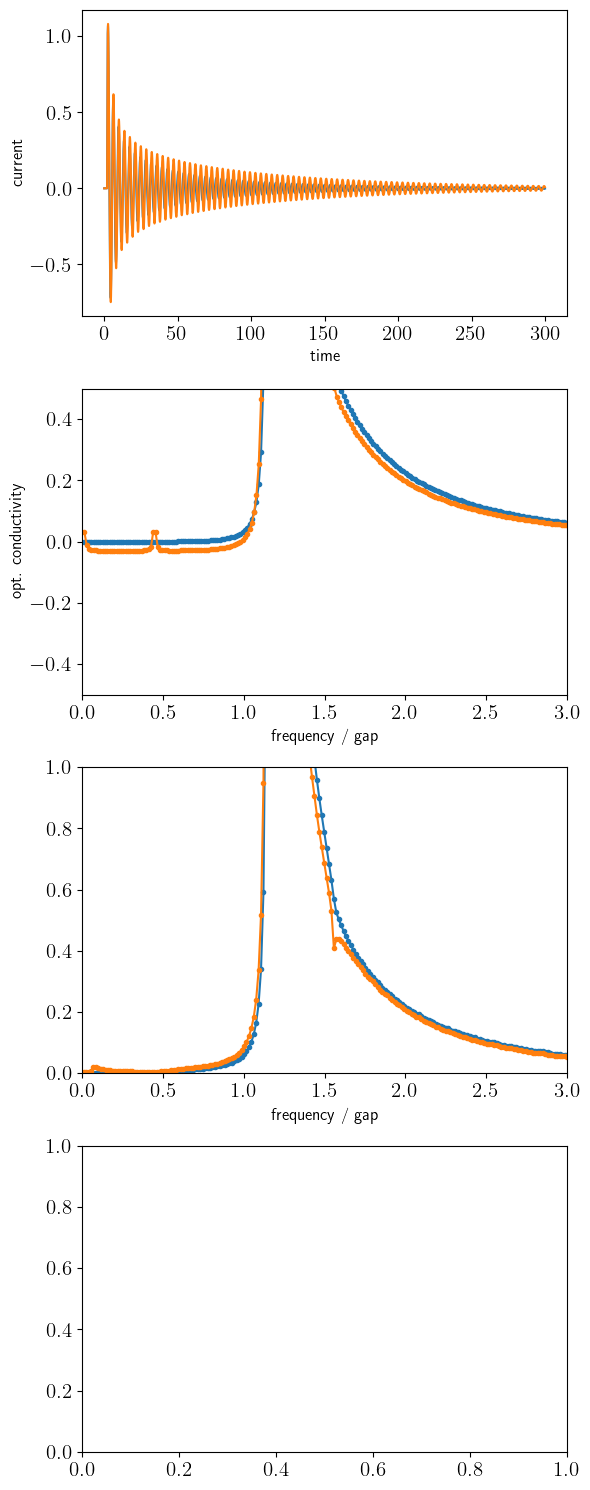

In [282]:
probe = A_pulz(time, A0, t0, sigma, omega0)
eta = 0.0
omega_cut = 5 * gap

fig, ax = plt.subplots(nrows=4, figsize=(6,15))
Omega, Sigma = optical_conductivity(time, measurement[:,0].real, probe, eta, omega_cut, Nk)
Omega, SigmaN = optical_conductivity(timeN, measurementN[:,0].real, probe, eta, omega_cut, Nk)

ax[0].ArtistList
ax[0].plot(time, measurement[:,0].real * np.exp(-eta * time))
ax[0].plot(timeN, measurementN[:,0].real * np.exp(-eta * time))
ax[0].set_xlabel(r'time'), ax[0].set_ylabel(r'current')

ax[1].plot(Omega / gap, Sigma, '.-')
ax[1].plot(Omega / gap, SigmaN, '.-')
ax[1].set_xlabel(r'frequency / gap'), ax[1].set_ylabel(r'opt. conductivity')
ax[1].set_xlim(0,3)
ax[1].set_ylim(-0.5,0.5)
ax[2].plot(omegas / gap, sigma_x, '.-')
ax[2].plot(omegas / gap, sigma_x - dsigma_x, '.-')
ax[2].set_xlabel(r'frequency / gap'), ax[1].set_ylabel(r'opt. conductivity')
ax[2].set_xlim(0,3)
ax[2].set_ylim(0,1)
plt.tight_layout()


(Text(0.5, 0, 'frequency / gap'), Text(0, 0.5, '$|\\text{FT(phase)}|^2$'))

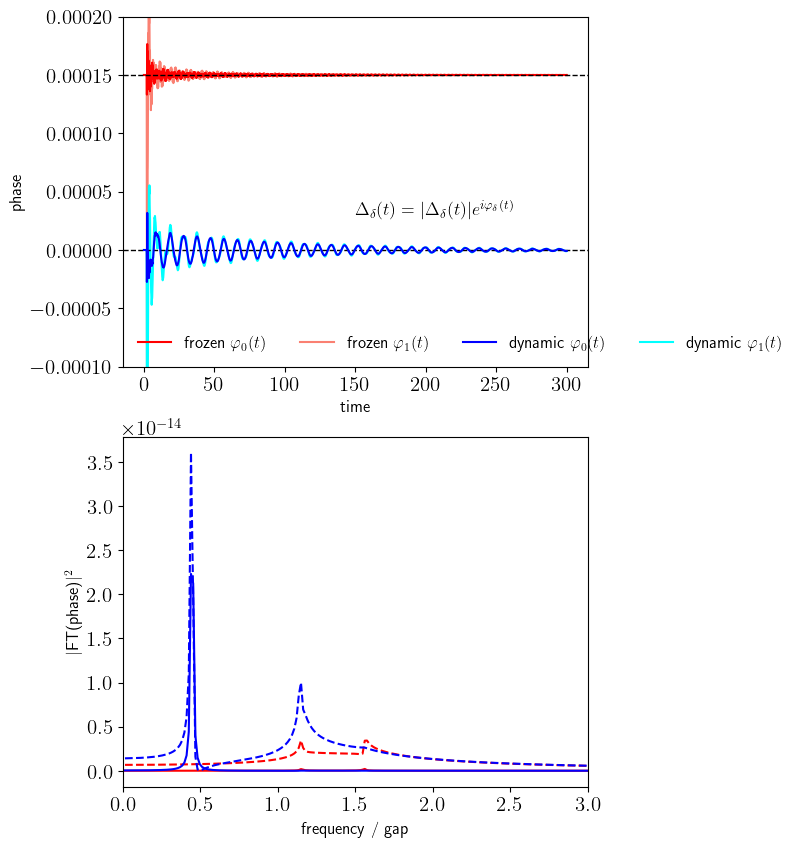

In [281]:
fig, ax = plt.subplots(nrows=2, figsize=(6,10))
phi_bN = np.angle(delta_bsN)
phi_cN = np.angle(delta_csN)
phi_b = np.angle(delta_bs)
phi_c = np.angle(delta_cs)

ax[0].plot(time, phi_b + 0.00015, color='red', label=r'frozen $\varphi_0(t)$')
ax[0].plot(time, phi_c + 0.00015, color='salmon', zorder=-100, label=r'frozen $\varphi_1(t)$')
ax[0].axhline(0.00015, color='black', lw=1, ls='dashed')
ax[0].axhline(0, color='black', ls='dashed', lw=1)

ax[0].plot(time, phi_bN, color='blue', label=r'dynamic $\varphi_0(t)$')
ax[0].plot(time, phi_cN, color='cyan', zorder=-100, label=r'dynamic $\varphi_1(t)$')
ax[0].set_ylim(-1e-4,1e-4*2)
ax[0].set_xlabel(r'time'), ax[0].set_ylabel(r'phase')
ax[0].legend(frameon=False, ncols=4)

ax[0].text(150, 3*1e-5, r'$\Delta_\delta(t) = |\Delta_\delta(t)|e^{i\varphi_\delta(t)}$', fontsize=13)

_, chi_b, _ = susceptibility(timeN, phi_b, probe, eta, omega_cut, m.Nk)
_, chi_c, _ = susceptibility(timeN, phi_c, probe, eta, omega_cut, m.Nk)

_, chi_bN, _ = susceptibility(timeN, phi_bN, probe, eta, omega_cut, m.Nk)
_, chi_cN, _ = susceptibility(timeN, phi_cN, probe, eta, omega_cut, m.Nk)
_, chi_bcN, _ = susceptibility(timeN, -phi_cN + phi_bN, probe, eta, omega_cut, m.Nk)

ax[1].plot(Omega / m.gap, np.abs(chi_b)**2, color='red')
ax[1].plot(Omega / m.gap, np.abs(chi_c)**2, color='red', ls='dashed')
ax[1].plot(Omega / m.gap, np.abs(chi_bN)**2, color='blue')
ax[1].plot(Omega / m.gap, np.abs(chi_cN)**2, color='blue', ls='dashed')

ax[1].set_xlim(0,3)
ax[1].set_xlabel(r'frequency / gap'), ax[1].set_ylabel(r'$|\text{FT(phase)}|^2$')
